In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
with open("knn_dataset_exercicio_2.csv", "r") as f:
    linhas = f.readlines()

dados = []
for linha in linhas:
    linha = linha.strip().strip('|')
    if '---' in linha:
        continue
    partes = [p.strip() for p in linha.split('|')]
    try:
        dados.append([float(p) for p in partes])
    except ValueError:
        continue

dataset = np.array(dados)

X_train = dataset[:, :2]
y_train = dataset[:, 2].astype(int)

print("Amostra das características (X_train):")
print(X_train[:5])
print("\nAmostra dos rótulos (y_train):")
print(y_train[:5])

Amostra das características (X_train):
[[  22. 1500.]
 [  25. 2000.]
 [  28. 2500.]
 [  30. 1000.]
 [  32. 1200.]]

Amostra dos rótulos (y_train):
[3 3 3 2 2]


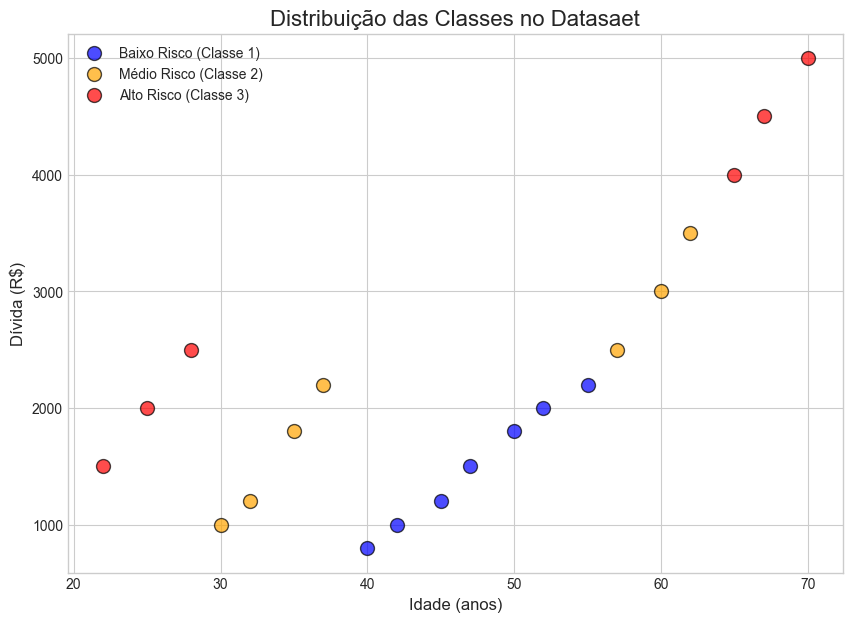

In [4]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10,7))

ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1,1],
           c='blue', s=100, edgecolor='k', alpha=0.7, label='Baixo Risco (Classe 1)')

ax.scatter(X_train[y_train == 2, 0], X_train[y_train == 2, 1],
           c='orange', s=100, edgecolor='k', alpha=0.7, label='Médio Risco (Classe 2)')

ax.scatter(X_train[y_train == 3, 0], X_train[y_train == 3, 1],
           c='red', s=100, edgecolor='k', alpha=0.7, label='Alto Risco (Classe 3)')

ax.set_title('Distribuição das Classes no Datasaet', fontsize=16)
ax.set_xlabel('Idade (anos)', fontsize=12)
ax.set_ylabel('Dívida (R$)', fontsize=12)
ax.legend()
plt.show()

In [5]:
def calcular_distancia_euclidiana(ponto1, ponto2):
    """Calcula a distância euclidiana entre dois pontos."""
    return np.sqrt(np.sum((ponto1 - ponto2)**2))

def encontrar_vizinhos(X_train, y_train, ponto_teste, k):
    """Encontra os k vizinhos mais próximos de um ponto teste."""
    
    distancias = []
    for i, ponto_treino in enumerate(X_train):
        dist = calcular_distancia_euclidiana(ponto_treino, ponto_teste)
        distancias.append((dist, y_train[i]))

        distancias.sort(key=lambda x: x[0])

    vizinhos = [distancia[1] for distancia in distancias[:k]]
    return vizinhos

In [6]:
def prever_classificacao(vizinhos):
    """Faz a previsão com base no voto marjoritário dos vizinhos"""

    contagem_votos = Counter(vizinhos)
    previsao = contagem_votos.most_common(1)[0][0]
    return previsao

novo_risco = np.array([50, 1000])
k = 1

vizinhos_proximos = encontrar_vizinhos(X_train, y_train, novo_risco, k)
previsao_final = prever_classificacao(vizinhos_proximos)

if previsao_final == 1:
    resultado_texto = "Baixo Risco"
elif previsao_final == 2:
    resultado_texto = "Médio Risco"
else:
    resultado_texto = "Alto Risco"

print(f"O novo risco tem as caracteristicas: {novo_risco}")
print(f"O valor de 'k' escolhido foi: {k}")
print(f"As classes dos vizinhos mais próximos são: {vizinhos_proximos}")
print("-------------------------------------------------------")
print(f"--> Previsão final: O novo risco é classificado como {resultado_texto} (Classe {previsao_final})")

O novo risco tem as caracteristicas: [  50 1000]
O valor de 'k' escolhido foi: 1
As classes dos vizinhos mais próximos são: [np.int64(1)]
-------------------------------------------------------
--> Previsão final: O novo risco é classificado como Baixo Risco (Classe 1)


In [7]:
def prever_classificacao(vizinhos):
    """Faz a previsão com base no voto marjoritário dos vizinhos"""

    contagem_votos = Counter(vizinhos)
    previsao = contagem_votos.most_common(1)[0][0]
    return previsao

novo_risco = np.array([50, 1000])
k = 1

vizinhos_proximos = encontrar_vizinhos(X_train, y_train, novo_risco, k)
previsao_final = prever_classificacao(vizinhos_proximos)

if previsao_final == 1:
    resultado_texto = "Baixo Risco"
elif previsao_final == 2:
    resultado_texto = "Médio Risco"
else:
    resultado_texto = "Alto Risco"

print(f"O novo risco tem as caracteristicas: {novo_risco}")
print(f"O valor de 'k' escolhido foi: {k}")
print(f"As classes dos vizinhos mais próximos são: {vizinhos_proximos}")
print("-------------------------------------------------------")
print(f"--> Previsão final: O novo risco é classificado como {resultado_texto} (Classe {previsao_final})")


O novo risco tem as caracteristicas: [  50 1000]
O valor de 'k' escolhido foi: 1
As classes dos vizinhos mais próximos são: [np.int64(1)]
-------------------------------------------------------
--> Previsão final: O novo risco é classificado como Baixo Risco (Classe 1)


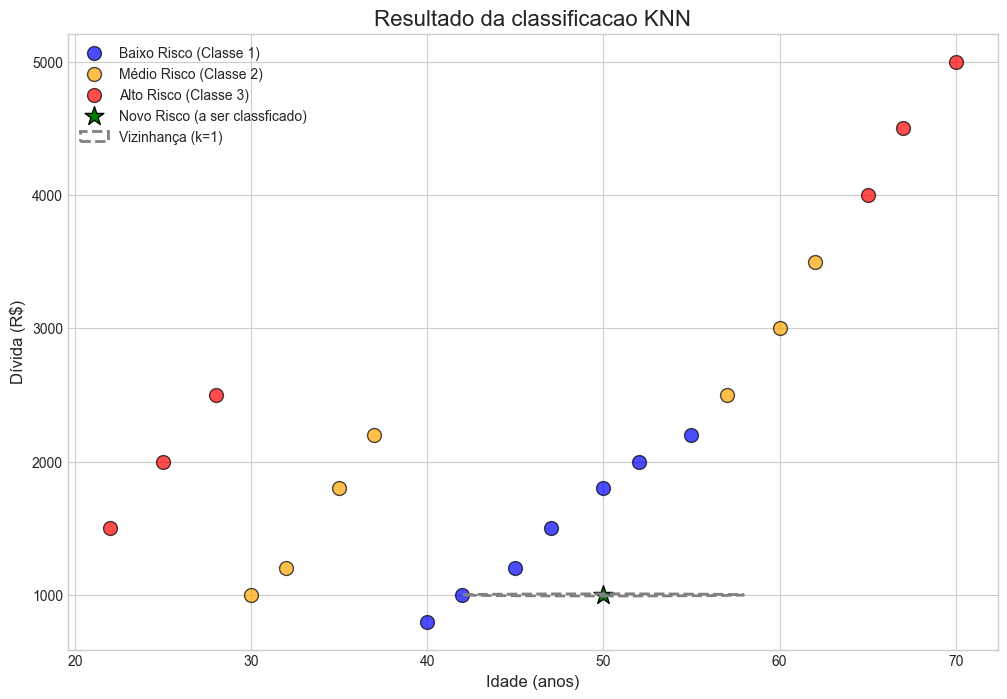

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1,1],
           c='blue', s=100, edgecolor='k', alpha=0.7, label='Baixo Risco (Classe 1)')

ax.scatter(X_train[y_train == 2, 0], X_train[y_train == 2, 1],
           c='orange', s=100, edgecolor='k', alpha=0.7, label='Médio Risco (Classe 2)')

ax.scatter(X_train[y_train == 3, 0], X_train[y_train == 3, 1],
           c='red', s=100, edgecolor='k', alpha=0.7, label='Alto Risco (Classe 3)')

ax.scatter(novo_risco[0], novo_risco[1], c='green', s=200,
           edgecolor='k', marker='*', label='Novo Risco (a ser classficado)')

indice_vizinhos = np.argsort([calcular_distancia_euclidiana(p, novo_risco) for p in X_train]) [:k]
pontos_vizinhos = X_train[indice_vizinhos]

distancia_maxima = calcular_distancia_euclidiana(novo_risco, pontos_vizinhos[-1])
circulo = plt.Circle(novo_risco, distancia_maxima, color='gray', fill=False,
                     linestyle='--', linewidth=2, label=f'Vizinhança (k={k})')
ax.add_artist(circulo)

ax.set_title('Resultado da classificacao KNN', fontsize=16)
ax.set_xlabel('Idade (anos)', fontsize=12)
ax.set_ylabel('Dívida (R$)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True)
plt.show()


## a- O modelo conseguiu diferenciar bem os clientes de alto risco em relação aos de baixo risco?

R: Sim, os de alto risco estão em dois extremos do gráfico, já os de baixo risco estão concentrados no meio.

## b- Existe sobreposição de clientes classificados como médio risco que poderiam ser confundidos com os outros grupos?

R: Sim, os clientes de médio risco aparecem distribuidos entre os grupos de baixo risco e alto risco, isso pode causar confusão na classificação, já que alguns clientes de médio risco possuem características próximas dos outros dois grupos.

## c- Qual seria o impacto de aumentar ou reduzir o valor de k na precisão da classificação de risco de crédito?

R: Um valor muito pequeno de k pode tornar as classificações instáveis, pois o modelo passa a considerar poucos vizinhos e fica mais sensível a valores atípicos nos dados (overfitting). Já um valor maior de k torna a decisão mais estável, pois considera mais vizinhos para definir a classe, porém pode generalizar demais e perder detalhes importantes dos padrões locais (underfitting).